In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import scipy

import Functions_14CO as F

from tqdm import tqdm

from time import time

from scipy.interpolate import interp1d

In [2]:
# setup pyplot formatting

axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '14' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

# Matlab Functions

In [3]:
#Credit to the top response of this stackoverflow question for converting the Matlab smooth function to python:
#https://stackoverflow.com/questions/40443020/matlabs-smooth-implementation-n-point-moving-average-in-numpy-python
def smooth(a,WSZ):
    # a: NumPy 1-D array containing the data to be smoothed
    # WSZ: smoothing window size needs, which must be odd number,
    # as in the original MATLAB implementation
    out0 = np.convolve(a,np.ones(WSZ,dtype=int),'valid')/WSZ    
    r = np.arange(1,WSZ-1,2)
    start = np.cumsum(a[:WSZ-1])[::2]/r
    stop = (np.cumsum(a[:-WSZ:-1])[::2]/r)[::-1]
    return np.concatenate((  start , out0, stop  ))

# smoothdiff(f,dx) differentiates f to x with timestep dx.
# df/dx = (0.5/dx)*([f f(N) f(N)]-[f(1) f(1) f]);
# what's going on here is we're taking the derivate over 2 steps of dx: df(i)/dx = (f[i+1]-f[i-1])/2dx
# at the edges, we just take the derivate over 1 step: df(0)/dx = (f[1]-f[0])/dx; df(-1)/dx = (f[-1]-f[-2])/dx
def smoothdiff(f,dx):
    #N = length(f);
    #if size(f,1) == 1
    #    out = (0.5/dx)*([f f(N) f(N)]-[f(1) f(1) f]); 
    #else
    #    out = (0.5/dx)*([f; f(N); f(N)]-[f(1); f(1); f]);     
    #end
    #out(N+2)=[]; out(1)=[];
    #out(N) = 2*out(N);
    #out(1) = 2*out(1);
    return np.concatenate(( [(f[1]-f[0])/dx], (0.5/dx)*(f[2:]-f[:-2]), [(f[-1]-f[-2])/dx] ), axis=0)

def C14_unit_convert(C14_in,unit_in,unit_out):#,date,d13C,MixR):
    # Constants
    Navo = 6.022140857E23
    scc_mol = 22414
    Aabs = 1.1764E-12
    tau = 8267
    
    # molec/ccSTP --> ppmE-12
    if (unit_in=='molec' and unit_out=='ppm'):
        return C14_in * scc_mol / Navo * 10**18;

    # ppmE-12 -> molec/ccSTP
    if (unit_in=='ppm' and unit_out=='molec'):
        return C14_in / scc_mol * Navo / 10**18;

In [4]:
def efilter(x, lambd): # x cannot grow or decay faster than an exponential rate
    
    for i in range(1,len(x)):
        if x[i]/x[i-1] > np.exp(1/lambd):
            x[i] = x[i-1]*np.exp(1/lambd)
        elif x[i]/x[i-1] < np.exp(-1/lambd):
            x[i] = x[i-1]*np.exp(-1/lambd)
    return x

# Firn_model_v5_cosmo_DomeC.m

Presented below is a one-to-one conversion of Firn_model_v5_cosmo_DomeC.m and any relevant subroutines from the original Matlab code to Python, with some optional modifications along the way for efficiency.

# Setup Parameters

Setup parameters for Space Mesh, Time Mesh, and atmospheric $^{14}$CO concentration.

In [5]:
dz = 0.25 #m
z_end = 110 #m

dt = 0.01 #yrs
t_end = 3000 #yrs
t_resol = 0.5 #yrs

In [6]:
# Constant 14CO atmospheric concentration
# full average of available NIWA ARH measurements provided by Hinrich
C14CO_const = 12 # constant 14CO history (molec/ccSTP)

## Initialise_DomeC.m

Initialize important parameters for Dome C

In [7]:
R = 8.314472 # gas constant (J/mol K)
g = 9.82 # gravity (m/s^2)
M_air = 28.96e-3 # molar mass of air (kg/mol)

N_over = 20 # points below close-off depth

pressure = 65800 # air pressure (Pa)
T = 273.15-54 # Temp (K)
Acc = 0.033 # Accumulation rate (meters of ice / yr)

Lockin = 96 #lock-in depth
Closeoff = 100 # close-off depth
D_0eddy = 2.55e-5 # convective diffusivity const.
H_eddy = 3 #1/e depth of convective layer
t_sample = 1999.05 # sample date

## Space_Mesh.m

Define our depth range $z$.

In [8]:
z_end = max(z_end, round(Closeoff + N_over * dz))
z = np.arange(0, z_end+1e-10, dz) #I add 1e-10 to the endpoint to try to match the inclusive endpoint of matlab's : operator
N = len(z)

## Time_Mesh.m

Define our low and high resolution time range.

In [9]:
M = round(t_end/dt + 1) # Num timesteps dt
P = round(t_end/t_resol + 1) # Num timesteps t_resol
P2 = t_resol/dt

t_low = t_sample - np.arange(t_end, -1e-10, -t_resol)
t_high = t_sample - np.arange(t_end, -1e-10, -dt)

#why not do:
#t_low = np.arange(t_sample-t_end, t_sample+1e-10, t_resol)
#t_high = np.arange(t_sample-t_end, t_sample+1e-10, dt)
#M = len(t_high)
#P = len(t_low)
#P2 = int(t_resol/dt)

## Density_DomeC.m

Define the ice density profile of Dome C and the open, closed, total porosity $s$ with depth.

$$s(z) = 1-\rho(z)/\rho_{ice}$$

$$s_c(z) = 0.37s(z) * (\frac{s(z)}{1-\rho_{co}/\rho_{ice}})^{-7.6}$$

$$s_o(z) = s(z) - s_c(z)$$

In [10]:
rho_ice = 0.9165 - (T-273.15)*1.4438e-4 - (T-273.15)**2 * 1.5175e-7 # Schwander et al.
rho_co = 0.833 # density at close off depth? idk

dens = np.array(pd.read_csv('Firn_Model_Density_DomeC.csv'))

# starting at 120m, exponential decay towards rho_ice
dens = np.concatenate((dens[:-1], np.array([np.arange(dens[-1,0], 200+1e-10, 0.2), ( dens[-1,1] + (rho_ice - dens[-1,1]) * (1-np.exp(-0.047 * (np.arange(dens[-1,0], 200+1e-10, 0.2) - 120))))]).T), axis=0)
dens[:,1] = smooth(dens[:,1], 9) #apply smoothing function

rho = np.interp(z, dens[:,0], dens[:,1])

#t=time()
#IceAge = np.array([np.trapezoid(rho[0:i+1],dx=dz) / (rho_ice * Acc) for i in range(N)])
#print(time()-t)

#t=time()
IceAge = scipy.integrate.cumulative_trapezoid(rho, dx=dz, initial=0) / (rho_ice * Acc)
#print(time()-t)
# ice age = mass depth / accumulation rate

s = 1 - rho/rho_ice # porosity of ice by depth

s_closed = (0.37 * s * (s/(1-rho_co/rho_ice))**(-7.6)).clip(max=s) # closed porosity
#s_closed = np.minimum(s_closed, s) # closed porosity <= total porosity

s_open = s - s_closed # open porosity

teller_co = np.argmax(s_closed) # depth index of maximum closed porosity (close off depth??)

Text(0.5, 1.0, 'Dome C Ice Density')

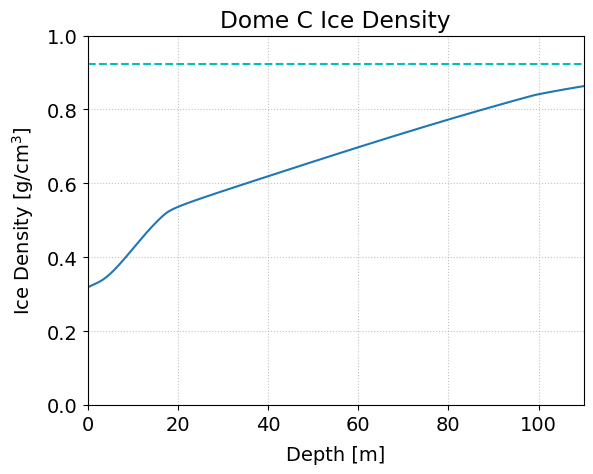

In [11]:
plt.axhline(rho_ice, c='c', ls='--')
plt.plot(z, rho)
plt.xlabel('Depth [m]')
plt.xlim(z[0],z[-1])
plt.ylabel(r'Ice Density [g/cm$^3$]')
plt.ylim(0,1)
plt.title('Dome C Ice Density')

Text(0.5, 1.0, 'Dome C Ice Porosity')

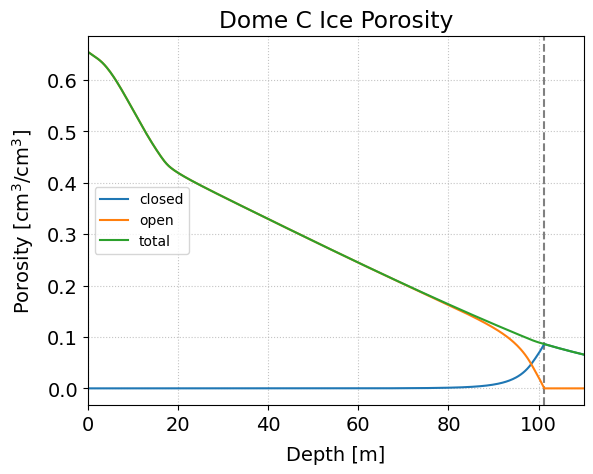

In [50]:
plt.axvline(z[teller_co], c='grey', ls='--')
plt.plot(z, s_closed, label='closed')
plt.plot(z, s_open, label='open')
plt.plot(z, s, label='total')
plt.xlim(z[0],z[-1])
plt.xlabel('Depth [m]')
plt.ylabel(r'Porosity [cm$^3$/cm$^3$]')
plt.legend(fontsize=10)
plt.title('Dome C Ice Porosity')

## Tortuosity_DomeC.m

Load the inverse tortuostiy and dispersive mixing profiles for Dome C.

(idk)

In [12]:
Profiles = np.array(pd.read_csv('Firn_Model_Tortuosity_DomeC.csv'))
InvTort = np.interp(z, Profiles[:,0], Profiles[:,1]) # inverse Tortuosity D(z) = D^0 * Inv tort
Diff_m = np.interp(z, Profiles[:,0], Profiles[:,2]) # dispersive mixing in lock-in zone

## Air Occlusion.m

In the firn, we calculate the bubble pressure by the integral:

$$b_p(z) = \frac{\int_0^z \frac{ds_c(z')}{dz'}e^{M_{air}g z'/RT} s(z') (1+\int_{z'}^z \frac{d\ln v_{ice}(z'')}{dz''} dz'')dz'}{s(z)\int_0^z \frac{ds_c(z')}{dz'} dz'} $$

I can't help but notice we're taking the integral of derivatives here.  Makes it pretty easy to simplify,

$$b_p(z) = \frac{\int_0^z \frac{ds_c(z')}{dz'}e^{M_{air}g z'/RT} s(z') [1+\ln v_{ice}(z) - \ln v_{ice}(z')]dz'}{s(z)[s_c(z)-s_c(0)]}$$

If we rearrange it to remove dependence on $z$ from our integral:

$$b_p(z) = \frac{(1+\ln v_{ice}(z))\int_0^z \frac{ds_c(z')}{dz'}e^{M_{air}g z'/RT} s(z')dz' - \int_0^z \ln v_{ice}(z') \frac{ds_c(z')}{dz'}e^{M_{air}g z'/RT} s(z') dz'}{s(z)[s_c(z)-s_c(0)]}$$

We can numerically calculate it with cumsum:

$$b_p(z) = \frac{(1+\ln v_{ice})*cumsum(dscl*C*s\,dz) - cumsum(dscl*C*s\ln v_{ice}\,dz)}{s(z)[s_c(z)-s_c(0)]};\quad dscl = \frac{ds_c(z)}{dz},\quad C = e^{M_{air}g z'/RT}$$

For depths below the close-off (max $s_c$), bubble pressure grows inverse to $s$ and $v_{ice}$:

$$b_p(z>z_{co}) = b_p(z_{co}) \frac{s(z_{co})v_{ice}(z_{co})}{s(z)v_{ice}(z)}$$

So all told,

$$b_p(z)= \begin{cases}\displaystyle
    \frac{(1+\ln v_{ice})\int_0^z dscl\,C\,s\,dz' - \int_0^z dscl\,C\,s\ln v_{ice}dz'}{s(z)[s_c(z)-s_c(0)]} & z\leq z_{co}\\ \displaystyle
    b_p(z_{co}) \frac{s(z_{co})v_{ice}(z_{co})}{s(z)v_{ice}(z)} & z > z_{co}
\end{cases}$$

We also calculate the constant flux below the closeoff depth:

$$flux = b_p(z_{co+1}) s_c(z_{co+1}) v_{ice}(z_{co+1})$$

The velocity:

$$v(z) = \begin{cases}\displaystyle
\frac{flux - v_{ice} * b_p * s_c}{C * s_o} & <v_{ice}(z)\\
v_{ice}(z) & \text{else}
\end{cases}$$

And the air content:

$$a_c = 1000 * \frac{b_p(z_{co+1}) * s_c(z_{co+1})}{\rho(z_{co+1})} * \frac{pressure}{101325} * \frac{273.15}{T}$$

In [13]:
bubble_pres = np.zeros(z.shape)

dscl = np.diff(s_closed, prepend=s_closed[0])/dz # ds_closed / dz

#s = s_open + s_closed # why not just use the old s value?
C = np.exp(M_air * g * z / (R * T) )
v_ice = Acc * rho_ice / rho # downwards ice velocity
strain = smoothdiff( np.log(v_ice), dz ) # d log(v_ice) / dz

#t = time()
#bubble_pres[:teller_co+1] = np.array([np.sum([dscl[j] * C[j] * s[j]/s[i] * (1 + np.trapezoid(strain[j:i+1], dx=dz)) for j in range(i+1)]) / np.sum([dscl[j] for j in range(i+1)]) for i in range(teller_co+1)])
#print(time()-t)

#t = time()
#strainsum = scipy.integrate.cumulative_trapezoid(strain, dx=dz, initial=0)
strainsum = np.log(v_ice)
bubble_pres = dz*(np.cumsum(dscl*C*s)*(1+strainsum) - np.cumsum(dscl*C*s*strainsum))/(s_closed-s_closed[0])/s
#print(time()-t)

# integrating the bubble pressure from the surface down to the close-off depth?
# After teller_co:

bubble_pres[teller_co+1:] = bubble_pres[teller_co] * s[teller_co] / s[teller_co+1:] * v_ice[teller_co] / v_ice[teller_co+1:]
# bubble pres is directly inverse to s and v_ice below close-off depth

# the initial division has a divide by zero error at the first index, so we set that to 1 now.
bubble_pres[0] = 1 # what are the units here??

flux = v_ice[teller_co+1] * bubble_pres[teller_co+1] * s_closed[teller_co+1]

velocity = np.minimum(v_ice, (flux + 1e-10 - v_ice * bubble_pres * s_closed) / ((s_open + 1e-10) * C) )

air_content = 1000 * bubble_pres[teller_co+1] * s_closed[teller_co+1] * pressure / 101325 * 273.15 / T / rho[teller_co+1]

/tmp/ipykernel_2556/3922497599.py:17: RuntimeWarning: invalid value encountered in divide
  bubble_pres = dz*(np.cumsum(dscl*C*s)*(1+strainsum) - np.cumsum(dscl*C*s*strainsum))/(s_closed-s_closed[0])/s


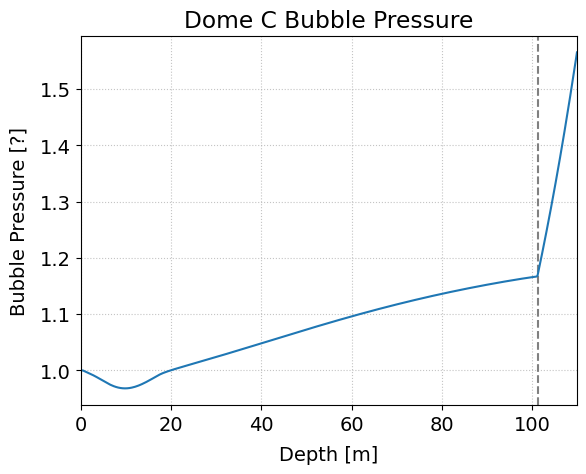

In [101]:
plt.axvline(z[teller_co], c='grey', ls='--')
plt.plot(z, bubble_pres)
plt.xlim(z[0],z[-1])
plt.xlabel('Depth [m]')
plt.ylabel('Bubble Pressure [?]')
plt.title('Dome C Bubble Pressure')
plt.show()

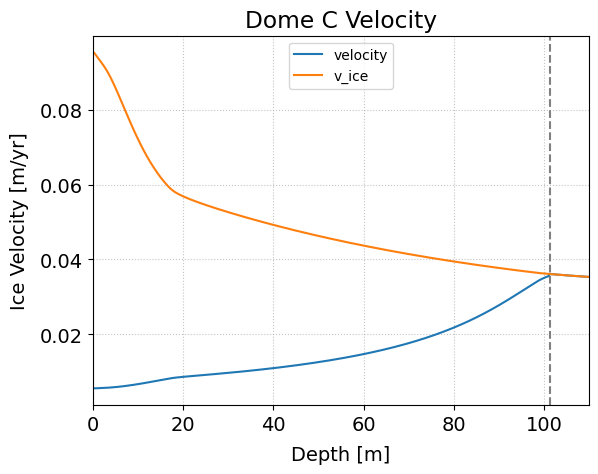

In [102]:
plt.axvline(z[teller_co], c='grey', ls='--')
plt.plot(z, velocity, label='velocity')
plt.plot(z, v_ice, label='v_ice')
plt.xlim(z[0],z[-1])
plt.xlabel('Depth [m]')
plt.ylabel('Ice Velocity [m/yr]')
plt.title('Dome C Velocity')
plt.legend(fontsize=10)

# Gas Properties

Load the properties for our gases (we only care about $^{14}$CO).

In [15]:
gases = {'C14_CO'}

## Load_Gas_Properties.m

Define the properties of each of our gases (again, just $^{14}$CO):

- The molar weight is 30 g/mol. ($^{14}$C + $^{16}$O) (=30e-3 kg/mol)
- Diffusivity is defined in proportion to the diffusivity of CO$_2$.
- The decay rate is 1/ the mean lifetime of $^{14}$C.

In [16]:
D_ref_CO2 = 5.75e-10 * T**1.81 * 101325 / pressure # CO2 diffusivity

M_gas, D_gas, decay_gas = dict(), dict(), dict()
M_gas['C14_CO'] = 30e-3 # molar weight [kg/mol]
D_gas['C14_CO'] = D_ref_CO2 * 1.25 * 0.9829926 # free air diffusivity w/ “sqrt of ratio of reduced masses”
decay_gas['C14_CO'] = 1/8267 # 1/mean lifetime [1/yr]

## Load_gas_history_ANT_DomeC.m

Establish the historical concentration of atmospheric $^{14}$CO. (assumed constant)

In [17]:
gas_history = dict()
gas_history['C14_CO'] = C14_unit_convert(C14CO_const, 'molec', 'ppm') * np.ones(M)

# Cosmogenic $^{14}$CO

## Calc_C14_ice.m

In this first half of the calculation we set up new depth & time bins (such that ice equivalent depth & age correspond), and define the scaling factors of $^{14}$C production and the partitioning ratios of $^{14}$C into different gas species (CO$_2$, CO, CH$_4$) and Reservoirs (fast, slow leakage).

We calculate the open / closed leakage rates w/ depth for each Reservoir and convert them to our COSmogenic depth grid.

In [116]:
COS_timesteps = 1 # int number of timesteps between t_resol output values (1-5)

COS_spinup = t_end * 1 + 1 #firn column spinup time in years

COS_scaling_method = 'LSDn0_BalcoMuons'

C14_partition_method = 'TG1516data'

COS_partition = np.array(
    [#CO2         CO          CH4
    [0.686307104, 0.31125305, 0.002439846], # neutron
    [0.686307104, 0.31125305, 0.002439846], # neg muon
    [0.686307104, 0.31125305, 0.002439846], # fast muon
])

COS_timevar = False # no time variation

COS_scaling = [16.95]

P0_tuning = np.array([1.03, 0.065, 0.07]) # minimal f-factors
P0_tuning = P0_tuning / np.array([1, COS_partition[0,1], COS_partition[0,1]])
# remove 14CO/14C fraction

# Divide 14CO between Reservoirs 1 & 2
Res_partition = np.array([0.9956, 0.0044])
Res_partition = Res_partition / np.sum(Res_partition) # normalize to sum = 1

leakage_open = np.array([1, 0.0045, 0.001])
leakage_closed = np.copy(leakage_open)

op_cl_prob_ratio = 1 # relative probability of leakage into open vs closed porosity per equiv. volume of each type

COS_leak_open = leakage_open.reshape((1,-1)) * (s_open * op_cl_prob_ratio / (s_open * op_cl_prob_ratio + s_closed)).reshape((-1,1))
COS_leak_closed = leakage_open.reshape((1,-1)) * (s_closed / (s_open * op_cl_prob_ratio + s_closed)).reshape((-1,1))
# leakage rates by depth & reservoir

Q = 1 + (COS_timesteps * (P-1))
COS_dt = t_resol / COS_timesteps
COS_t = t_sample - np.arange(t_end, -1e-10, -COS_dt)
#COS_t = np.arange(t_sample-t_end, t_sample+1e-10, COS_dt)

#ice-eqiv depth
COS_dz = Acc * COS_dt
COS_z = np.arange(COS_dz/2, dz * np.sum(rho)/rho_ice + 2 * dz, COS_dz) # depth bin centers

# we create a fine grid to integrate the density
# why not just use a trapezoidal sum?  it's literally a linear interpolation
#dummy = np.interp(np.arange(0, z_end + 3*dz, 0.01), [*z, z[-1]+30], [*rho, rho_ice])

# interpolate COS_z to real depth, integrating “dummy” density to get mass depth ranges
#COS_zr = np.interp(COS_z, 0.01 * np.cumsum( [0, *((dummy[:-1] + dummy[1:])/2)] )/rho_ice, np.arange(0, z_end + 3*dz, 0.01))
COS_zr = np.interp(COS_z, scipy.integrate.cumulative_trapezoid([*rho, rho_ice], x=[*z, z[-1]+30], initial=0)/rho_ice, [*z, z[-1]+30])

COS_leak_open = interp1d(z, COS_leak_open, bounds_error=False, fill_value=(COS_leak_open[0], COS_leak_open[-1]), axis=0, assume_sorted=True)(COS_zr)
COS_leak_closed = interp1d(z, COS_leak_closed, bounds_error=False, fill_value=(COS_leak_closed[0], COS_leak_closed[-1]), axis=0, assume_sorted=True)(COS_zr)

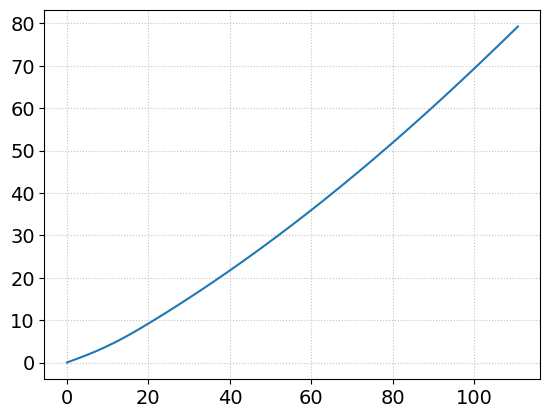

In [117]:
plt.plot(COS_zr, COS_z)

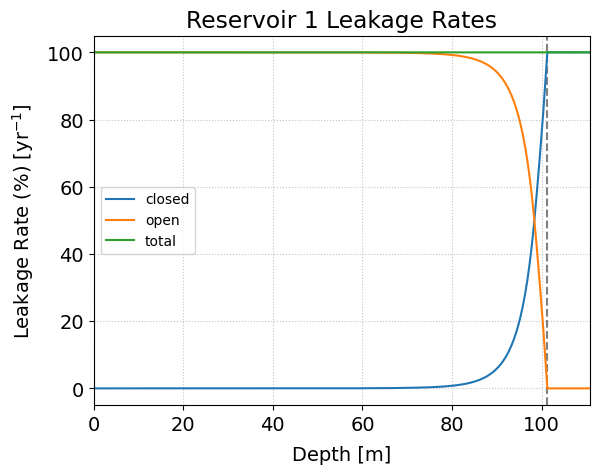

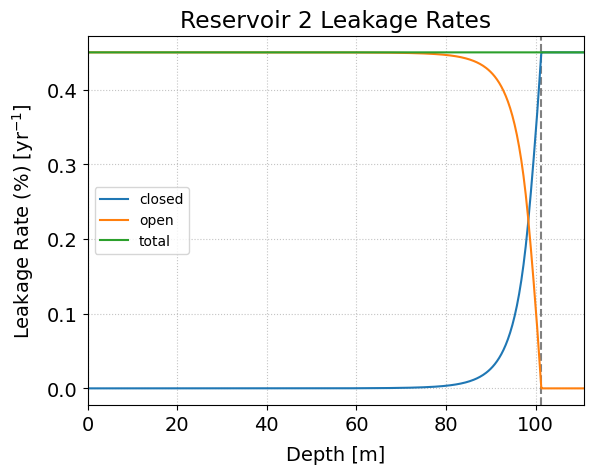

In [118]:
for r in range(len(Res_partition)):
    plt.axvline(z[teller_co], c='grey', ls='--')
    plt.plot(COS_zr, COS_leak_closed[:,r]*100, label='closed')
    plt.plot(COS_zr, COS_leak_open[:,r]*100, label='open')
    plt.plot(COS_zr, (COS_leak_open[:,r]+COS_leak_closed[:,r])*100, label='total')
    plt.xlim(z[0], COS_zr[-1])
    plt.xlabel('Depth [m]')
    plt.ylabel(r'Leakage Rate (%) [yr$^{-1}$]')
    plt.legend(fontsize=10)
    plt.title('Reservoir {} Leakage Rates'.format(r+1))
    plt.show()

## COS_Production.m

Here, the $^{14}$C production rates are calculated.

The neutron production rate is given by a surface measurement, rescaled to match our site (Dome C) and medium (ice rather than quartz), applying our tuning factor and then decaying exponentially with mass depth.

$$P_n(z) = f_n P_n^*(0)e^{-\Lambda z}$$

The negative muon capture and fast muon interaction production rates are found with Balco's modification of the Heisinger calculation, then scaled by our tuning factors.

In [119]:
def COS_Production(z, scaling_site):
    Pn0_SLHL = 12.76 # Borchers ‘16
    QtzToIce = 60.08 / 2 / 18.02 # conversion for O-atom density difference between quartz and ice

    Pn = Pn0_SLHL * QtzToIce * scaling_site[0] * P0_tuning[0] * np.exp(-100 * z * rho_ice/150)

    Balco_mu_neg, Balco_mu_fast = F.Balco_P_mu_total(100*z*rho_ice, pressure/100)

    Pmu = Balco_mu_neg * P0_tuning[1]
    Pmuf = Balco_mu_fast * P0_tuning[2]
    
    return Pn, Pmu, Pmuf

COS_Pn, COS_Pmu, COS_Pmuf = COS_Production(z=COS_z, scaling_site=COS_scaling)

Text(0.5, 1.0, 'Dome C $^{14}$C Production Rates')

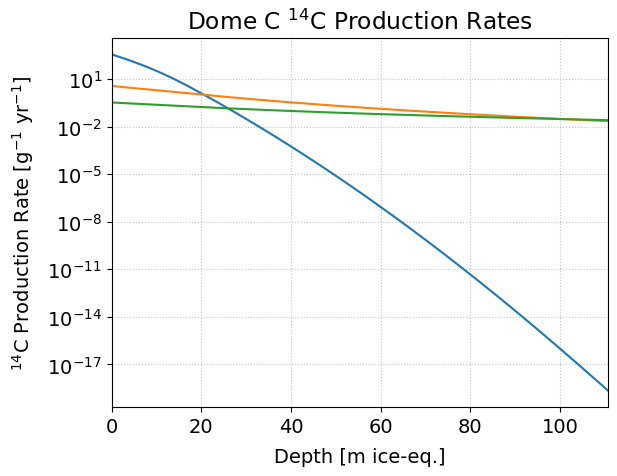

In [120]:
plt.plot(COS_zr, COS_Pn)
plt.plot(COS_zr, COS_Pmu)
plt.plot(COS_zr, COS_Pmuf)
plt.xlim(z[0],COS_zr[-1])
plt.xlabel('Depth [m ice-eq.]')
plt.yscale('log')
plt.ylabel(r'$^{14}$C Production Rate [g$^{-1}$ yr$^{-1}$]')
plt.title(r'Dome C $^{14}$C Production Rates')

## Calc_C14_ice.m cont.


In [121]:
C14_grains = np.zeros((N, P, 3, len(Res_partition)))
C14_leak_open = np.copy(C14_grains)
C14_leak_closed = np.copy(C14_grains)
C14_cumuleak_open = np.copy(C14_grains)
C14_cumuleak_closed = np.copy(C14_grains)

COS_P = np.array([COS_Pn, COS_Pmu, COS_Pmuf]).T

loop_method = False

if loop_method: # takes about a minute to run
    #spinup
    for r in range(len(Res_partition)):
        COS_Ctemp = np.zeros((len(COS_z),3))
        COS_cumuopen_temp = np.copy(COS_Ctemp)
        COS_cumuclosed_temp = np.copy(COS_Ctemp)

        for i in tqdm(range(int(COS_spinup / COS_dt))):
            #step 1 : 100% of production
            COS_Ctemp += Res_partition[r] * COS_dt * (COS_P @ COS_partition)

            #step 2 : Leakage
            dummy = (COS_Ctemp - COS_Ctemp * (( 1-COS_leak_closed[:,r] - COS_leak_open[:,r] ).clip(min=0)**COS_dt).reshape((-1,1))) / COS_dt # annual leakage
            COS_Ctemp = (COS_Ctemp * ((1-COS_leak_closed[:,r] - COS_leak_open[:, r]).clip(min=0)**COS_dt).reshape((-1,1)))

            #all of the cumulative leakage before advection
            COS_cumuopen_temp += COS_dt * dummy * (COS_leak_open[:,r] / (COS_leak_open[:,r] + COS_leak_closed[:,r])).reshape((-1,1))
            COS_cumuclosed_temp += COS_dt * dummy * (COS_leak_closed[:,r] / (COS_leak_open[:,r] + COS_leak_closed[:,r])).reshape((-1,1))

            #step 3 : decay
            COS_Ctemp *= np.exp(-COS_dt/8267)
            COS_cumuopen_temp *= np.exp(-COS_dt/8267)
            COS_cumuclosed_temp *= np.exp(-COS_dt/8267)

            #step 4 : advection - add fresh ice at the top & step down
            COS_Ctemp = np.concatenate(([np.zeros(3)], COS_Ctemp[:-1]), axis=0)
            COS_cumuopen_temp = np.concatenate(([np.zeros(3)], COS_cumuopen_temp[:-1]), axis=0)
            COS_cumuclosed_temp = np.concatenate(([np.zeros(3)], COS_cumuclosed_temp[:-1]), axis=0)

        for j in range(3):
            C14_grains[:,0,j,r]          = np.interp(z, [0,*COS_zr], [0,*COS_Ctemp[:,j]])
            C14_leak_open[:,0,j,r]       = np.interp(z, [0,*COS_zr], [0,*dummy[:,j]*(COS_leak_open[:,r]/(COS_leak_closed[:,r]+COS_leak_open[:,r]))])
            C14_leak_closed[:,0,j,r]     = np.interp(z, [0,*COS_zr], [0,*dummy[:,j]*(COS_leak_closed[:,r]/(COS_leak_closed[:,r]+COS_leak_open[:,r]))])
            C14_cumuleak_open[:,0,j,r]   = np.interp(z, [0,*COS_zr], [0,*COS_cumuopen_temp[:,j]])
            C14_cumuleak_closed[:,0,j,r] = np.interp(z, [0,*COS_zr], [0,*COS_cumuclosed_temp[:,j]])

        for i in tqdm(range(1,Q)):
            #step 1 : 100% of production
            COS_Ctemp += Res_partition[r] * COS_dt * (COS_P @ COS_partition)

            #step 2 : Leakage
            dummy = (COS_Ctemp - COS_Ctemp * (( 1-COS_leak_closed[:,r] - COS_leak_open[:,r] ).clip(min=0)**COS_dt).reshape((-1,1))) / COS_dt # annual leakage
            COS_Ctemp = (COS_Ctemp * ((1-COS_leak_closed[:,r] - COS_leak_open[:, r]).clip(min=0)**COS_dt).reshape((-1,1)))

            #all of the cumulative leakage before advection
            COS_cumuopen_temp += COS_dt * dummy * (COS_leak_open[:,r] / (COS_leak_open[:,r] + COS_leak_closed[:,r])).reshape((-1,1))
            COS_cumuclosed_temp += COS_dt * dummy * (COS_leak_closed[:,r] / (COS_leak_open[:,r] + COS_leak_closed[:,r])).reshape((-1,1))

            #step 3 : decay
            COS_Ctemp *= np.exp(-COS_dt/8267)
            COS_cumuopen_temp *= np.exp(-COS_dt/8267)
            COS_cumuclosed_temp *= np.exp(-COS_dt/8267)

            #step 4 : advection - add fresh ice at the top & step down
            COS_Ctemp = np.concatenate(([np.zeros(3)], COS_Ctemp[:-1]), axis=0)
            COS_cumuopen_temp = np.concatenate(([np.zeros(3)], COS_cumuopen_temp[:-1]), axis=0)
            COS_cumuclosed_temp = np.concatenate(([np.zeros(3)], COS_cumuclosed_temp[:-1]), axis=0)

            if i % COS_timesteps==0:
                i2 = int(i/COS_timesteps)
                for j in range(3):
                    C14_grains[:,i2,j,r]          = np.interp(z, [0,*COS_zr], [0,*COS_Ctemp[:,j]])
                    C14_leak_open[:,i2,j,r]       = np.interp(z, [0,*COS_zr], [0,*dummy[:,j]*(COS_leak_open[:,r]/(COS_leak_closed[:,r]+COS_leak_open[:,r]))])
                    C14_leak_closed[:,i2,j,r]     = np.interp(z, [0,*COS_zr], [0,*dummy[:,j]*(COS_leak_closed[:,r]/(COS_leak_closed[:,r]+COS_leak_open[:,r]))])
                    C14_cumuleak_open[:,i2,j,r]   = np.interp(z, [0,*COS_zr], [0,*COS_cumuopen_temp[:,j]])
                    C14_cumuleak_closed[:,i2,j,r] = np.interp(z, [0,*COS_zr], [0,*COS_cumuclosed_temp[:,j]])

### Cumsum solution by Walter:

The original calculation finds the $^{14}$C concentration in ice grains by integrating $Ctemp$:

$Ctemp_{i+1} = (Ctemp_{i} + R_p (P\cdot C_p)\,dt) * (1-l_c-l_o)^{dt} e^{-\lambda dt}$

Converting this back to a differential equation, we get:

$dCtemp = R_p (P\cdot C_p)\,dt - (Ctemp + R_p (P\cdot C_p)\,dt) * (\lambda + l_{tot}) \,dt;\quad l_{tot} = -\ln(1-l_c-l_o)$

Where $l_{tot}$ is the total effective loss rate to leakage.  Eliminating any terms where $dt^2 \ll dt$,

$dCtemp = R_p (P\cdot C_p)\,dt - Ctemp (\lambda + l_{tot}) \,dt$

Integrating this gives:

$Ctemp(t) = \int_0^t R_p (P(t')\cdot C_p) e^{-\lambda (t-t')} e^{-\int_{t'}^t l_{tot}(t'')\, dt''} dt'$

Removing constant factors from the integral,

$Ctemp(t) = R_p e^{-\lambda t - \int_0^t l_{tot}(t'')\, dt''} \int_0^t (P(t')\cdot C_p) e^{\lambda t' + \int_0^{t'} l_{tot}(t'')\, dt''} dt'$

Which we can solve numerically by cumulative sums:

$Ctemp(t) = R_p e^{-\lambda t - l_{sum}(t)} cumsum(P(t)\cdot C_p e^{\lambda t + l_{sum}(t)}dt); \quad l_{sum} = cumsum(l_{tot}(t)dt)$

Note that unlike the previous method which tracked $^{14}$C over both depth & time separately, here we're tracking an indivudal parcel along its depth histories $z(t)$ and using the simplifying fact that all ice parcels have the same depths and production rates by age.

If we instead wanted to allow $z(t)$ to be different for different parcels, or $P(z)$ to change over time, we would need to switch to a calculation similar to the Accumulation tensor described in my In Situ $^{14}$CO calculation, with a modification to allow for loss due to leakage.

(An ice parcel with total leakage rate $l_{tot}(z)$ and depth history $z(t)$ has a total leakage factor $\exp(-\int_{t}^{t_f} l_{tot}(z(t'))\,dt')$ for $^{14}$C produced at time $t$.)

The open/closed leakage rates are given by the concentration in the ice grains + 1 timestep of raw production, times the total fraction leaked per timestep, times the fraction which leaks to open / closed porosity:

$Lclose_i = (Ctemp_i + R_p * dt * (P \cdot C_p)) * (1 - ( 1-l_c - l_o)^{dt}) /dt * l_c / (l_c+l_o)$

$Lclose(t) = (Ctemp(t)/dt + R_p * (P(t) \cdot C_p)) * (1 - ( 1-l_c - l_o)^{dt}) * l_c / (l_c+l_o)$

$Lopen(t) = (Ctemp(t)/dt + R_p * (P(t) \cdot C_p)) * (1 - ( 1-l_c - l_o)^{dt}) * l_o / (l_c+l_o)$

We can't eliminate the $P(t)$ term even though it would seem to be an order of magnitude $(1\ll 1/dt)$ smaller than $Ctemp/dt$, because if the leakage rate is 100\% (as it is in Reservoir 1), then $Ctemp=0$, and $(1-(1-l_c-l_0)^{dt})$ doesn't go to 0 in the limit $dt\rightarrow 0$.

Finally, the cumulative leaked $^{14}$C is calculated by integrating the leakage rates, minus decay:

$Cclose_{i+1} = (Cclose_i + (Ctemp_i + R_p * dt * (P \cdot C_p)) * (1 - ( 1-l_c - l_o)^{dt}) * l_c / (l_c+l_o)) * e^{-\lambda dt}$

$Cclose_{i+1} = (Cclose_i + Lclose_i\,dt) * e^{-\lambda dt}$

Converting this to a differential equation:

$dCclose = Lclose_i\,dt - (Cclose_i+Lclose_i\,dt) \lambda\,dt$

And eliminating terms $dt^2\ll dt$:

$dCclose = Lclose_i\,dt - Cclose_i\,\lambda\,dt$

Which we integrate:

$Cclose(t) = \int_0^t Lclose(t')\, e^{-\lambda(t-t')}\,dt'$

Taking constant factors out of the integral:

$Cclose(t) = e^{-\lambda t}\int_0^t Lclose(t')\, e^{\lambda t'}\,dt'$

We numerically solve with a cumulative sum:

$Cclose(t) = e^{-\lambda t} cumsum(Lclose(t) e^{\lambda t}\, dt)$

$Copen(t) = e^{-\lambda t} cumsum(Lopen(t) e^{\lambda t}\, dt)$

I don't know why we bother calculating this, when the following section provides a more robust estimate using bubble tracking.

In [122]:
t = time()

COS_age = (np.arange(len(COS_z))*COS_dt+COS_dt/2).reshape((-1,1,1)) # age of ice at ice-eq depth COS_z

lambd = 1/8267 #14C decay rate
# integrate total leakage over time
lsum = np.cumsum(-np.log(1-COS_leak_closed - COS_leak_open)[:,:len(Res_partition)]*COS_dt, axis=0).reshape((-1,1,len(Res_partition)))
# integrate new 14C production rate - loss to decay & leakage
Ctemp = Res_partition.reshape((1,1,-1)) * np.exp(-lambd*COS_age-lsum) * np.cumsum((COS_P @ COS_partition).reshape((-1,3,1)) * np.exp(lambd*COS_age + lsum) * COS_dt, axis=0)
Ctemp[~np.isfinite(Ctemp)] = 0
#axis0 - Depth (=Ice Age)
#axis1 - Gas species (14CO2, 14CO, 14CH4)
#axis2 - Reservoir

#14C Concentration in ice grains
grains = Ctemp

#14C leaked into open porosity per timestep
leak_open = (Ctemp/COS_dt + Res_partition.reshape((1,1,-1)) * (COS_P @ COS_partition).reshape((-1,3,1))) * ((1-(1-COS_leak_open-COS_leak_closed).clip(min=0)**COS_dt) * COS_leak_open/(COS_leak_open+COS_leak_closed))[:,:len(Res_partition)].reshape((-1,1,len(Res_partition)))
#14C leaked into closed porosity per timestep
leak_closed = (Ctemp/COS_dt + Res_partition.reshape((1,1,-1)) * (COS_P @ COS_partition).reshape((-1,3,1))) * ((1-(1-COS_leak_open-COS_leak_closed).clip(min=0)**COS_dt) * COS_leak_closed/(COS_leak_open+COS_leak_closed))[:,:len(Res_partition)].reshape((-1,1,len(Res_partition)))

#14C stored in open porosity (no bubble tracking)
cumuleak_open = np.exp(-lambd*COS_age) * np.cumsum(leak_open * np.exp(lambd*COS_age) * COS_dt, axis=0)
#14C stored in closed porosity (no bubble tracking)
cumuleak_closed = np.exp(-lambd*COS_age) * np.cumsum(leak_closed * np.exp(lambd*COS_age) * COS_dt, axis=0)
#axis0 - Depth (=Ice Age)
#axis1 - Gas Species (14CO2, 14CO, 14CH4)
#axis2 - Reservoir

grains_z = interp1d([0,*COS_zr], np.concatenate((np.zeros((1,*grains.shape[1:])),grains), axis=0), axis=0, assume_sorted=True)(z)
leak_open_z = interp1d([0,*COS_zr], np.concatenate((np.zeros((1,*grains.shape[1:])),leak_open), axis=0), axis=0, assume_sorted=True)(z)
leak_closed_z = interp1d([0,*COS_zr], np.concatenate((np.zeros((1,*grains.shape[1:])),leak_closed), axis=0), axis=0, assume_sorted=True)(z)
cumuleak_open_z = interp1d([0,*COS_zr], np.concatenate((np.zeros((1,*grains.shape[1:])),cumuleak_open), axis=0), axis=0, assume_sorted=True)(z)
cumuleak_closed_z = interp1d([0,*COS_zr], np.concatenate((np.zeros((1,*grains.shape[1:])),cumuleak_closed), axis=0), axis=0, assume_sorted=True)(z)

if not loop_method:
    C14_grains = np.repeat(grains_z.reshape((grains_z.shape[0],1,*grains_z.shape[1:])), P, axis=1)
    C14_leak_open = np.repeat(leak_open_z.reshape((leak_open_z.shape[0],1,*grains_z.shape[1:])), P, axis=1)
    C14_leak_closed = np.repeat(leak_closed_z.reshape((leak_closed_z.shape[0],1,*grains_z.shape[1:])), P, axis=1)
    C14_cumuleak_open = np.repeat(cumuleak_open_z.reshape((cumuleak_open_z.shape[0],1,*grains_z.shape[1:])), P, axis=1)
    C14_cumuleak_closed = np.repeat(cumuleak_closed_z.reshape((cumuleak_closed_z.shape[0],1,*grains_z.shape[1:])), P, axis=1)

print(time()-t)

0.09688162803649902


/tmp/ipykernel_2556/1566417441.py:7: RuntimeWarning: divide by zero encountered in log
  lsum = np.cumsum(-np.log(1-COS_leak_closed - COS_leak_open)[:,:len(Res_partition)]*COS_dt, axis=0).reshape((-1,1,len(Res_partition)))
/tmp/ipykernel_2556/1566417441.py:7: RuntimeWarning: invalid value encountered in log
  lsum = np.cumsum(-np.log(1-COS_leak_closed - COS_leak_open)[:,:len(Res_partition)]*COS_dt, axis=0).reshape((-1,1,len(Res_partition)))
/tmp/ipykernel_2556/1566417441.py:9: RuntimeWarning: invalid value encountered in multiply
  Ctemp = Res_partition.reshape((1,1,-1)) * np.exp(-lambd*COS_age-lsum) * np.cumsum((COS_P @ COS_partition).reshape((-1,3,1)) * np.exp(lambd*COS_age + lsum) * COS_dt, axis=0)


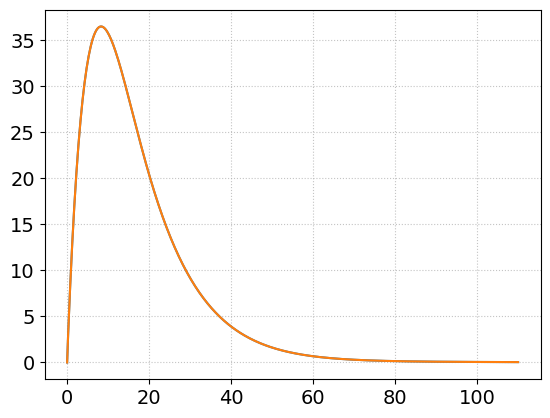

In [123]:
r = 1
plt.plot(z, C14_grains[:,-1,0,r])
plt.plot(z, grains_z[:,0,r])

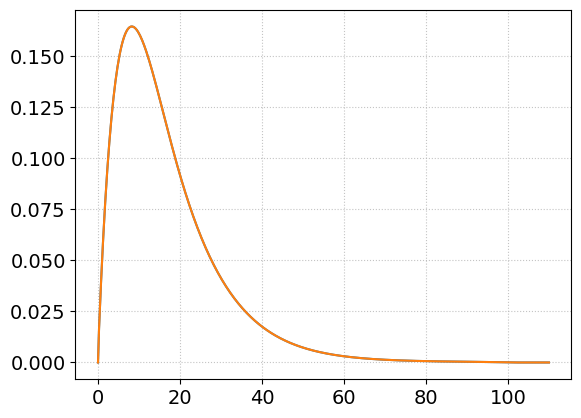

In [124]:
r = 1
plt.plot(z, C14_leak_open[:,-1,0,r])
plt.plot(z, leak_open_z[:,0,r])

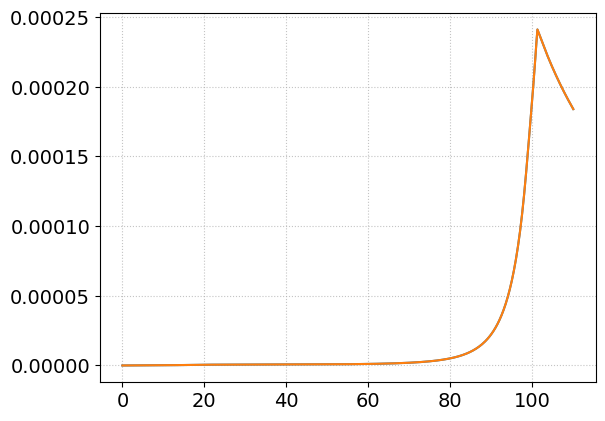

In [125]:
r = 1
plt.plot(z, C14_leak_closed[:,-1,0,r])
plt.plot(z, leak_closed_z[:,0,r])

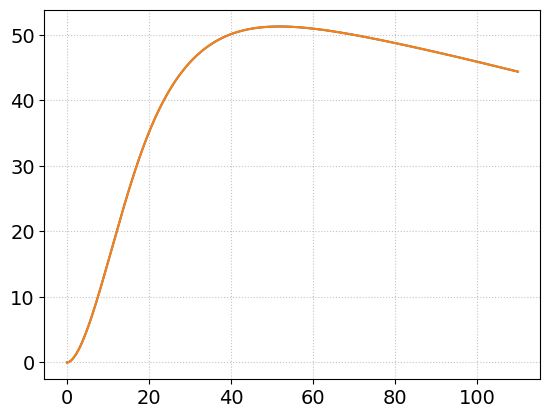

In [126]:
r = 1
plt.plot(z, C14_cumuleak_open[:,-1,0,r])
plt.plot(z, cumuleak_open_z[:,0,r])

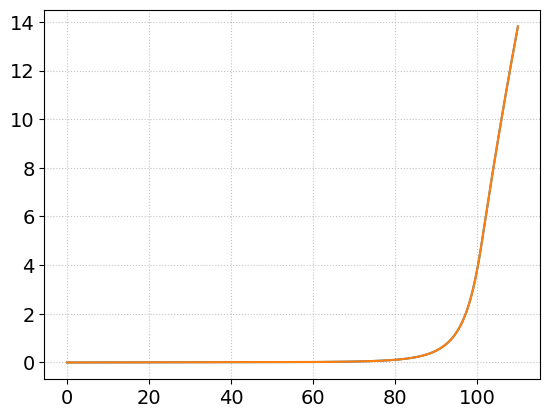

In [127]:
r = 0
plt.plot(z, C14_cumuleak_closed[:,-1,0,r])
plt.plot(z, cumuleak_closed_z[:,0,r])

In [128]:
# sum over reservoirs
C14_grains = np.sum(C14_grains, axis=-1)
C14_leak_open = np.sum(C14_leak_open, axis=-1)
C14_leak_closed = np.sum(C14_leak_closed, axis=-1)
C14_cumuleak_open = np.sum(C14_cumuleak_open, axis=-1)
C14_cumuleak_closed = np.sum(C14_cumuleak_closed, axis=-1)
#axis0 - Depth
#axis1 - Time
#axis2 - Gas Species

In [129]:
# We interpolated from z to COS_zr and now we're interpolating back to z??
# Whyyy???
COS_leak_open = np.array([np.interp(z, [0,*COS_zr], [COS_leak_open[0,i], *COS_leak_open[:,i]]) for i in range(len(Res_partition))]).T
COS_leak_closed = np.array([np.interp(z, [0,*COS_zr], [COS_leak_closed[0,i], *COS_leak_closed[:,i]]) for i in range(len(Res_partition))]).T

# Calculate Profiles

### Diffusion Equation

The differential equation describing the diffusion of our open porosity gas concentration $c$ is:

$$\frac{\partial}{\partial t}c = \alpha\frac{\partial^2}{\partial z^2}c + \beta\frac{\partial}{\partial z}c + \gamma c$$

where

$$\alpha = D + D_e$$

$$\beta = \frac{[D*(M_{air}-M_{trace}) + D_e*M_{air}]*g}{R*T} + \frac{d((D+D_e)*C_{air}*s_o)}{s_o*C_{air}\,dz} - v$$

$$\gamma = \frac{d(D*C_{air}*s_o)}{s_o*C_{air}\,dz}\frac{(M_{air}-M_{trace})*g}{R*T} - L_{trace}$$

$D = InvTort * D_{trace}$ - Diffusivity

$D_e$ - Eddie diffusivity

$C_{air} = e^{M_{air}gz/RT}$ - "Barometric equation", open porosity pressure relative to surface, I think?

$M_{air}$ - molar mass of air

$M_{trace}$ - molar mass of $^{14}$CO

$L_{trace}$ - decay rate of $^{14}$CO

The function below calculates $\alpha' = \alpha \frac{dt}{2dz^2}$, $\beta' = \beta \frac{dt}{4dz}$, and $\gamma' = \gamma \frac{dt}{2}$, for reasons that will be explained in the following section.

In [130]:
def Crank_abc(z,dz,dt,s_open,s_closed,M_air,M_trace,D_trace,L_trace,g,R,T,D_0eddy, H_eddy,InvTort,Diff_m,velocity):

    teller_co = np.arange(len(s_open))[s_open==0][0]
    s = s_open+s_closed
    s_open = s_open + 1e-9     # add a small number to make sure 1/s_open doesn't blow up
    C_air = np.exp(M_air*g*z/(R*T))  # Barometric equation

    velocity = velocity/(60*60*24*365.25) # convert to m/s
    L_trace = L_trace/(60*60*24*365.25)

    # Molecular diffusivity part:
    Diff   =  InvTort*D_trace

    # Eddy diffusivity part:
    Diff_e = efilter(D_0eddy*np.exp(-z/H_eddy),0.5/dz)*(z<55) # Convection following Kawamura et al
    Diff_e = np.maximum(Diff_e,Diff_m)    # Add dispersion in the LIZ

    # Take the derivatives
    porecl = smoothdiff(Diff*C_air*s_open,dz)/(s_open*C_air)
    porecl_e = smoothdiff(Diff_e*C_air*s_open,dz)/(s_open*C_air)

    porecl[teller_co]   = porecl[teller_co+1]
    porecl_e[teller_co] = porecl_e[teller_co+1]

    # c_t = alpha*c_zz + beta*c_z + gamma*c
    alpha =  (dt*60*60*24*365.25/(2*dz**2)) * (Diff+Diff_e)
    beta  =  (dt*60*60*24*365.25/(4*dz)) * (Diff*(M_air-M_trace)*g/(R*T) + (Diff_e)*(M_air)*g/(R*T) + porecl + porecl_e -velocity)
    gamma =  (dt*60*60*24*365.25/2) * (porecl*(M_air-M_trace)*g/(R*T) +  -L_trace)
    return alpha, beta, gamma

### Crank-Nicholson

To solve the diffusion PDE:

$$\frac{\partial}{\partial t}c = \alpha\frac{\partial^2}{\partial z^2}c + \beta\frac{\partial}{\partial z}c + \gamma c$$

We approximate our spatial derivates as the average between timesteps $t+1$ and $t$:

$$\frac{c^{t+1}-c^t}{\Delta t} = \frac{\alpha}{2(\Delta z)^2}((c^{t+1}_{i+1}-2c^{t+1}_i+c^{t+1}_{i-1})+(c^t_{i+1}-2c^t_i+c^t_{i-1})) + \frac{\beta}{4\Delta z}((c^{t+1}_{i+1}-c^{t+1}_{i-1})+(c^t_{i+1}-c^t_{i-1})) + \frac{\gamma}{2}(c^{t+1}_i + c^{t}_i)$$

Moving our timesteps $t+1$ and $t$ to opposite sides of the equation,

$$-(\alpha' + \beta')c^{t+1}_{i+1} + (1 + 2\alpha' - \gamma')c^{t+1}_i - (\alpha' - \beta')c^{t+1}_{i-1} = (\alpha' + \beta')c^{t}_{i+1} + (1 - 2\alpha' + \gamma')c^{t}_i + (\alpha' - \beta')c^{t}_{i-1}$$

We can rewrite this as a matrix product on $c^{t+1}$ and $c^t$:

$$A_{i,i-1} = \alpha'_i - \beta'_i; \quad A_{i,i} = -2\alpha'_i + \gamma'_i; \quad A_{i,i+1} = \alpha'_i + \beta'_i$$

$$(I-A)c^{t+1} = (I+A)c^t$$

Which we can solve by inversion:

$$c^{t+1} = (I-A)^{-1}(I+A)c^t$$

The ice starts uniformly filled with the same $^{14}$CO concentration as the atmosphere.

After each timestep, the concentration at the top of the ice is set to the current atmospheric $^{14}$CO concentration.

Cosmogenic $^{14}$CO is also being injected into our gas, so after each timestep we add the extra $^{14}$CO leaking out of the grains.

In [131]:
def CrankNic(alpha,beta,gamma,M,N,P,P2,teller_co,c_forcing,N_over,C14_add=None):
    # this solves the diffusion equation c_t = alpha*c_xx + beta*c_x + gamma*c 
    # using finite-differences in space and Crank-Nicolson time-stepping.  
    # t_0 is the initial time, t_end is the final time, N is the number of mesh-points, 
    # and M is the number of time steps.

    c_gases = np.zeros((N,P))
    Q = teller_co+N_over

    if not (C14_add is None) and len(C14_add)<Q:
        C14_add = np.concatenate((C14_add, np.zeros((Q-len(C14_add), M))), axis=0)

    # define the matrix A which has to be inverted at every time-step.
    # A = zeros(Q,Q);
    RHS = np.zeros(Q)
    #c_temp = np.zeros(Q)


    # A(1,1) = 1;
    # A(1,2) = 0;
    # for i=2:(Q-1)
    #     A(i,i-1) = -1*(alpha(i) - beta(i))  ;
    #     A(i,i) = 1+2*alpha(i)-gamma(i);
    #     A(i,i+1) = -1*(alpha(i) + beta(i))  ;
    # end
    # A(Q,Q) = 1;  %1+2*alpha(1)-gamma(1);
    # A(Q,Q-1) = -1; %-1*(alpha(Q-1) - beta(Q-1));

    # Defining A as a sparse matrix instead saves 40% computation time at dz=1,
    # and 87% at dz = 0.25. This is implemented on line below.
    #A = spdiags([[-1*(alpha(2:(Q-1)) - beta(2:(Q-1))) ; -1; 0] [1; 1+2*alpha(2:(Q-1))-gamma(2:(Q-1))  ; 1] [0 ;0; -1*(alpha(2:(Q-1)) + beta(2:(Q-1)))  ]], -1:1, Q, Q)
    
    A_for = scipy.sparse.diags_array(
        [
            np.concatenate((alpha[1:Q] - beta[1:Q], [0])),
            np.concatenate(([1], 1-2*alpha[1:Q]+gamma[1:Q], [0])),
            np.concatenate(([0], alpha[1:Q] + beta[1:Q] )),
        ],
        offsets=np.arange(-1,2), shape=(Q,Q)
    )
    
    A_back = scipy.sparse.diags_array(
        [
            np.concatenate((-1*(alpha[1:Q] - beta[1:Q]), [-1])),
            np.concatenate(([1], 1+2*alpha[1:Q]-gamma[1:Q], [1])),
            np.concatenate(([0], -1*(alpha[1:Q] + beta[1:Q]) )),
        ],
        offsets=np.arange(-1,2), shape=(Q,Q)
    )
    
    # Initialise the firn with constant mixing ratio throughout
    c_temp = c_forcing[0]*np.ones(Q)
    
    A_inv = scipy.sparse.linalg.inv(A_back)
    
    #A_tot = A_inv @ A_for

    # Solve the forward PDE:
    for j in tqdm(range(M-1)):
        # Save the profile only at selected time resolution:
        if j%P2 == 0:
            c_gases[:Q,int(j/P2)] = c_temp
            c_gases[Q:,int(j/P2)] = c_temp[-1]

        # Solve the CN implicite time stepping:
        #RHS[0] = c_temp[0]       # right hand side of Crank-Nicolson equation
        #for i in range(1,Q-1):
            #RHS[i] = (alpha[i] - beta[i])*c_temp[i-1] + (1 - 2*alpha[i] + gamma[i])*c_temp[i] + (alpha[i] + beta[i])*c_temp[i+1]
        #RHS[1:Q-1] = (alpha - beta)[1:Q-1]*c_temp[0:Q-2] + (1 - 2*alpha + gamma)[1:Q-1]*c_temp[1:Q-1] + (alpha + beta)[1:Q-1]*c_temp[2:Q]
        
        #RHS[-1] = 0 # (alpha(Q) - beta(Q))*c_temp(Q-1) + (1 - 2*alpha(Q) + gamma(Q))*c_temp(Q);
        RHS = A_for @ c_temp
        
        #c_temp = A\RHS; % Matrix inversion!! Go MATLAB!!
        c_temp = A_inv @ RHS # I already did the matrix inversion... Go Python!!
        #c_temp = A_tot @ c_temp
        
        if not (C14_add is None):
            c_temp = c_temp + C14_add[:Q,j]
        c_temp[0] = c_forcing[j+1] # c(Q,j+1)= 1; % 0.5* c(Q-1,j+1) + 0.5* c(Q,j);
    
    
    c_gases[:Q,-1] = c_temp
    c_gases[Q:,-1] = c_temp[-1]
    
    return c_gases

**Note:** If we want a faster way of doing this integral, maybe try diagonalizing $(I-A)^{-1}(I+A) = A_{tot}$:

$$A_{tot} = S \Lambda S^T$$

$$c^t = A_{tot}^tc^0 = S \Lambda^t S^T c^0$$

If we're introducing extra $c$ along the way, we can make this a 2D vector $C_{add}$:

$$c^t = S \sum_{t'=0}^t\Lambda^{t-t'} S^T C_{add}^{t'}; \quad C_{add}(z,t) = 
\begin{cases}
c^{\text{atm}}(t)& z=0 \lor t=0\\
c^{\text{in situ}}(z,t)& \text{else}
\end{cases}$$

Which can be accomplished by taking the diagonal $\vec{\lambda}$ of $\Lambda$ and raising it to the power of $\vec{t}$, multiplying that elementwise with $S \cdot C_{add}$:

$$c^t = S \sum_{t'=0}^t\vec{\lambda}^{t-t'} * S^T\cdot C_{add}^{t'}$$

Idk, is there a good way to do this sort of exponential convolution?

I could split off the $t$ part of the exponential and do another cumsum:

$$c^t = S \cdot (\lambda^t * cumsum(\lambda^{-t'} * S^T\cdot C_{add}^{t'}))$$

but with $t$ going into the thousands this is going to be incredibly unstable.

Maybe just np.convolve would work, but then I need to do it one eigenvector at a time w/ list comprehension...

In [132]:
def CrankNic_eig(alpha,beta,gamma,M,N,P,P2,teller_co,c_forcing,N_over,C14_add=None):
    # UNSTABLE, and also slower (tragic...)

    c_gases = np.zeros((N,P))
    Q = teller_co+N_over
    
    if C14_add is None:
        C14_add = np.zeros((Q,M))
    elif len(C14_add)<Q:
        C14_add = np.concatenate((C14_add, np.zeros((Q-len(C14_add), M))), axis=0)
    elif len(C14_add)>Q:
        C14_add = C14_add[:Q]
    
    C14_add[:,0] = c_forcing[0]
    C14_add[0] = c_forcing
    
    A_for = scipy.sparse.diags_array(
        [
            np.concatenate((alpha[1:Q] - beta[1:Q], [0])),
            np.concatenate(([1], 1-2*alpha[1:Q]+gamma[1:Q], [0])),
            np.concatenate(([0], alpha[1:Q] + beta[1:Q] )),
        ],
        offsets=np.arange(-1,2), shape=(Q,Q)
    )
    
    A_back = scipy.sparse.diags_array(
        [
            np.concatenate((-1*(alpha[1:Q] - beta[1:Q]), [-1])),
            np.concatenate(([1], 1+2*alpha[1:Q]-gamma[1:Q], [1])),
            np.concatenate(([0], -1*(alpha[1:Q] + beta[1:Q]) )),
        ],
        offsets=np.arange(-1,2), shape=(Q,Q)
    )
    
    print('Inverting...')
    t=time()
    A_inv = scipy.sparse.linalg.inv(A_back)
    print(time()-t)
    
    A_tot = A_inv @ A_for
    A_tot[0] = 0
    
    print('Solving for eigenvectors...')
    t=time()
    A_val, A_vec = np.linalg.eig(A_tot.toarray())
    A_val, A_vec = A_val[A_val != 0], A_vec[:,A_val !=0]
    print(time()-t)
    
    print(A_val)
    
    print('Convolving...')
    t=time()
    Aexp = A_val.reshape((-1,1))**np.arange(M)
    t_exp_max = np.arange(M)[np.max(np.abs(Aexp),axis=0)>1e-10][-1] # last time t s.t. eigenvalue^t > 1e-10
    Aexp = Aexp[:,:t_exp_max+1]
    
    Cvec = A_vec.T @ C14_add
    c_temp = A_vec @ np.array(# convolve over time for each eigenvector
        [np.convolve(Cvec[i], Aexp[i])[:M] for i in tqdm(range(len(Cvec)))]
    )[:,np.arange(P)*int(P2)]
    print(time()-t)
    
    c_gases[:Q] = c_temp
    c_gases[Q:] = c_temp[-1]
    
    return c_gases

### Bubble Tracking

The trapping rate of open porosity gas into closed porosity gas is given by the change in the number density of closed porsosity gas particles per unit time:

$$trapping(z) = \frac{d}{dt} = \rho(z)\frac{d(s_c*b_p)}{dz}$$

Since all of these new gas particles entering the closed porosity of our ice parcel come from the open porosity, the additional $^{14}$CO concentration ($c(z)$) they bring is the integral over time of the open porosity concentration ($c_o(z,t)$) times the trapping rate ($tr(z)$) times the fraction of $^{14}$C which has since decayed ($e^{-\lambda (t-t')}$), divided by the total gas in closed porosity ($\int_{t_0}^t tr(z(t'))\,dt'$).

$$c(z,t) = \frac{\int_{t_0}^{t} c_o(z(t'),t')\,tr(z(t'))\,e^{-\lambda (t-t')}\,dt'}{\int_{t_0}^t tr(z(t'))\,dt'}$$

In [133]:
def Bubbletracking_all(z,dz,t_low,t_resol,c_open,Acc,IceAge,velocity,bubble_pres,rho,rho_ice,s_closed,s_open, M_air,g,R,T,teller_co,decay,finalone):
    # Calculate the concentrations in the closed bubbles for all the time
    # steps using a 2-D interpolation

    # Calcluate trapping rates. Both formulas give the same values. (if
    # everything is implemented correctly. CHECK THIS)
    C_air = np.exp(M_air*g*z/(R*T))
    N = len(z)
    M = len(t_low)
    M2 = M
    icevel = Acc*rho_ice/rho
    # trapping = -1*(dz./icevel).*smoothdiff(velocity.*s_open.*C_air,dz);
    #trapping_t = (1/icevel)*Acc*rho_ice*smoothdiff(s_closed*bubble_pres/rho,dz)
    trapping_t = rho*smoothdiff(s_closed*bubble_pres/rho,dz) # Acc*rho_ice/(Acc*rho_ice/rho) = rho
    #trapping_z = (dz./icevel).*Acc.*rho_ice.*smoothdiff(s_closed.*bubble_pres./rho,dz);


    if -1*min(t_low) < IceAge[-1]:
        t_low = np.arange(-int(IceAge[-1]+1), 0, t_resol)
        c_open = np.concatenate((c_open[0,0]*ones((N, len(t_low)-c_open.shape[1])), c_open), axis=1)
        print('  The total model run time is too short and has been adjusted.')
        print('  It is recommended that you re-run the model with the correct run time,')
        print('  which must exceed {} years.'.format(int(IceAge[-1]+1)))
        M = length(t_low)


    ## Old method: intergrate along z
    # # Interpolation of c_open to determine which values go into the integral
    # t_aug = [(min(t_low)-2*t_resol),(min(t_low)-t_resol) ,t_low, t_resol, 2*t_resol ];
    # [T_AUG,Z_AUG] = meshgrid(t_aug,z);
    # 
    # [Z_I,dummy] = meshgrid(z,z);
    # [T1,T2] = meshgrid(1:N,1:N);
    # T_I = IceAge(T1)-IceAge(T2);
    # T_I(T_I>max(t_low)) = max(t_aug);
    # T_I(T_I<min(t_low)) = min(t_aug);

    # c_openpores = c_open;
    # c_closed = zeros(size(c_open));
    # c_total  = zeros(size(c_open));
    # 
    # 
    # # First we run the final one
    # c_open_aug = [c_open(:,1),c_open(:,1),c_open,zeros(N,2)];
    # fullair_aug = [zeros(N,2),ones(size(c_open)),zeros(N,2)];
    # 
    # c_interp        = interp2(T_AUG,Z_AUG,c_open_aug,T_I,Z_I);
    # fullair_interp  = interp2(T_AUG,Z_AUG,fullair_aug,T_I,Z_I);
    # 
    # fullair_closed = dz*fullair_interp*trapping_z;
    # fullytrapped = fullair_closed; fullytrapped((teller_co+1):end) = fullytrapped(teller_co+1);
    # fullair_total = s_open.*C_air+s_closed.*bubble_pres;
    # 
    # c_closed(:,M) = dz*c_interp*trapping_z./fullytrapped;
    #c_total(:,M)  = (c_closed(:,M).*s_closed.*bubble_pres + c_openpores(:,M).*s_open.*C_air)./fullair_total;
    # 
    # % Now solve it for the earlier ones
    # for i = 1:(M-1)
    #     c_open_aug = [c_open(1,1)*ones(N,(M+2-i)),c_open(:,1:i),zeros(N,2)];
    #     c_interp   = interp2(T_AUG,Z_AUG,c_open_aug,T_I,Z_I);
    #     c_closed(:,i) = dz*c_interp*trapping_z./fullytrapped;
    #     c_total(:,i)  = (c_closed(:,i).*s_closed.*bubble_pres + c_openpores(:,i).*s_open.*C_air)./fullair_total;
    #     if  mod(i,250)==0
    #     display(['  Progress = ', num2str(i/M*100),' percent'])
    #     end
    # end
    # 
    # c_openpores((teller_co:end),:) = NaN;

    #% New method: integrate along t

    c_openpores = c_open
    c_closed = np.zeros(c_open.shape)
    c_total  = np.zeros(c_open.shape)

    M_position = np.zeros((N,M))
    M_c_ones = np.ones((N,M))
    M_position[:,-1] = z

    # interpolate past ice parcel depths, with negative depths for unformed ice.
    for i in range(1,M):
        M_position[:,M-i-1] = np.interp((IceAge-i*t_resol), [-100000, -IceAge[1], *IceAge], [-10, -z[1], *z])
    #M_position - ice parcel depth history
    #axis0 - ice parcel final depth
    #axis1 - time

    #epsilon = interp1([-100000; -IceAge(2); IceAge], [-10; -z(2); z],-t_resol);
    #M_position(M_position <= epsilon) = -10;
    #M_c_ones(M_position <= epsilon) = 0;
    M_position[M_position < 0] = -10
    M_c_ones[M_position < 0 ] = 0 # = 1 if ice has formed, else 0
    
    # interpolate gas trapping rates (open -> closed porosity) at past ice parcel depths
    M_trapping = np.interp(M_position, [-10,-dz,*z], [0,trapping_t[0],*trapping_t])

    fullair_total = s_open*C_air + s_closed*bubble_pres

    if finalone:
        P=1
    else:
        P=M

    for i in range(P):
        M_c_open = np.zeros((N,M))
        M_c_open[:,-1] = c_open[:,-i-1]
        for j in range(M-i-1):
            # interpolate from past parcel depth to past open porosity concentration, times 14C decay
            M_c_open[:,-j-2] = np.interp(M_position[:,M-j-2], [-10, -dz, *z], [0, c_open[1,-j-i-2], *c_open[:,-j-i-2]]) * np.exp(-(j+1)*t_resol*decay)
        
        # integrate trapped 14C from open porosity over time
        c_closed[:,-i-1] = np.sum(M_c_open * M_trapping, axis=1) / np.sum(M_c_ones * M_trapping, axis=1)
        # average over open & closed concentrations (never used)
        c_total[:,-i-1]  = (c_closed[:,M-i-2] * s_closed * bubble_pres + c_openpores[:,M-i-2] * s_open * C_air) / fullair_total

    #     if  mod(i,20)==0
    #     display(['  Progress = ', num2str(i/M*100),' percent'])
    #     end

    # in case runtime was extended:
    if M > M2:
        c_openpores = c_openpores[:, (M-M2):]
        c_closed = c_closed[:, (M-M2):]
        c_total = c_total[:, (M-M2):]
    
    # openpore concentration undefined below close-off depth
    c_openpores[teller_co:, :] = np.nan
    
    return c_openpores, c_closed, c_total

## Calc_profiles_openclosed.m

We run the above formulae for each of our gases (just $^{14}$CO), converting to and from ppm, to find the final concentration in our open & closed porosity.

```
c_open = concentration in open pores (C14_leak_open + atmospheric, integrated w/ CrankNic)
c_closed = concentration leaked into closed pores directly from ice grains (C14_cumuleak_closed)
         + concentration trapped into closed pores from open pores (c_open, integrated w/ Bubbletracking_all)
```

In [134]:
final_t_only = True

In [135]:
c_profiles = np.zeros((len(gases),N))
c_profiles_cl = np.zeros((len(gases),N))

C14_open = np.zeros(C14_grains.shape)
C14_closed = np.zeros(C14_grains.shape)

for i,gas in enumerate(gases): # For each gas separately
    # The PDE is split up as c_t = alpha*c_zz + beta*c_z + gamma*c below
    # the alpha, beta and gamma are defined
    alpha,beta,gamma = Crank_abc(z,dz,dt,s_open,s_closed,M_air,M_gas[gas],D_gas[gas],decay_gas[gas],g,R,T,D_0eddy, H_eddy,InvTort,Diff_m,velocity)
    # we run a crank nicolson implicit scheme to solve the PDE
    if 'C14_' in gas:       
        # Calculate the nr of air molecules per gram of ice, to convert the leakage rate to ppm
        # To keep numbers reasonable, we use units of 1E-12 ppm, as was done in Buizert et al. 2012
        # Vas note: increased coefficients at start of expression to
        # 1e18, as ppm*10^-12 requires. Also added division by rho in
        # the denominators - this is needed to go from grams to cm^3
        gram_to_ppm = 1e18*R*T / (6.022140857e23*pressure*s_open/rho*np.exp(M_air*g*z/(R*T))*1e-6)
        gram_to_ppm[teller_co:N+1] = 0
        gram_to_ppm_cl = 1e18*R*T / (6.022140857e23*pressure*s_closed/rho*bubble_pres*1e-6)
        if gas == 'C14_CO2':
                C14_add    = dt * interp1d(t_low, C14_leak_open[:,:,0], axis=1, assume_sorted=True, bounds_error=False, fill_value=(C14_leak_open[:,0,0],C14_leak_open[:,-1,0]))(t_high) * gram_to_ppm.reshape((-1,1))
                C14_add_cl = C14_cumuleak_closed[:,:,0] * gram_to_ppm_cl.reshape((-1,1))
        elif gas=='C14_CO':
                C14_add    = dt * interp1d(t_low, C14_leak_open[:,:,1], axis=1, assume_sorted=True, bounds_error=False, fill_value=(C14_leak_open[:,0,1],C14_leak_open[:,-1,1]))(t_high) * gram_to_ppm.reshape((-1,1))
                C14_add_cl = C14_cumuleak_closed[:,:,1] * gram_to_ppm_cl.reshape((-1,1))
        elif gas=='C14_CH4':
                C14_add    = dt * interp1d(t_low, C14_leak_open[:,:,2], axis=1, assume_sorted=True, bounds_error=False, fill_value=(C14_leak_open[:,0,2],C14_leak_open[:,-1,2]))(t_high) * gram_to_ppm.reshape((-1,1))
                C14_add_cl = C14_cumuleak_closed[:,:,2] * gram_to_ppm_cl.reshape((-1,1))
        
        c_gases = CrankNic(alpha,beta,gamma,M,N,P,P2,teller_co,gas_history[gas],N_over,C14_add)   
        # now calculate the closed pores as well;
        c_open, c_closed, c_total = Bubbletracking_all(z,dz,t_low-t_sample,t_resol,c_gases,Acc,IceAge,velocity,bubble_pres,rho,rho_ice,s_closed,s_open, M_air,g,R,T,teller_co,decay_gas[gas],final_t_only)       
        c_closed = c_closed + C14_add_cl
        #c_total = [] # c_total is meaningless in this context.

        # Now we go back to atoms 14C per gram
        # Vas note: I adjusted this equation accordingly as well
        ppm_to_gram = (6.022140857e23 * pressure * s_open / rho * np.exp(M_air*g*z/(R*T))*1e-6)/(1e18*R*T)
        ppm_to_gram[teller_co:N+1] = 0
        ppm_to_gram_cl = (6.022140857e23 * pressure * s_closed / rho * bubble_pres * 1e-6)/(1e18*R*T)

        if gas == 'C14_CO2':
            C14_open[:,:,0]   = c_open * ppm_to_gram.reshape((-1,1))
            C14_closed[:,:,0] = c_closed * ppm_to_gram_cl.reshape((-1,1))
        elif gas=='C14_CO':
            C14_open[:,:,1]   = c_open * ppm_to_gram.reshape((-1,1))
            C14_closed[:,:,1] = c_closed * ppm_to_gram_cl.reshape((-1,1))
        elif gas=='C14_CH4':
            C14_open[:,:,2]   = c_open * ppm_to_gram.reshape((-1,1))
            C14_closed[:,:,2] = c_closed * ppm_to_gram_cl.reshape((-1,1))
        C14_open[np.isnan(C14_open)] = 0
    else:
        c_gases = CrankNic(alpha,beta,gamma,M,N,P,P2,teller_co,gas_history[gas],N_over)
        # now calculate the closed pores as well;
        c_open, c_closed, c_total = Bubbletracking_all(z,dz,t_low-t_sample,t_resol,c_gases,Acc,IceAge,velocity,bubble_pres,rho,rho_ice,s_closed,s_open, M_air,g,R,T,teller_co,decay_gas[gas],final_t_only)   

    c_profiles[i,:] = c_open[:,-1]
    c_profiles_cl[i,:] = c_closed[:,-1]
    print('  Calculated open and closed profiles for gas {} out of {}'.format(i+1, len(gases)))

/tmp/ipykernel_2556/3015062468.py:18: RuntimeWarning: divide by zero encountered in divide
  gram_to_ppm = 1e18*R*T / (6.022140857e23*pressure*s_open/rho*np.exp(M_air*g*z/(R*T))*1e-6)
100%|█████████████████████████████████████████████████████████████████████████| 300000/300000 [00:54<00:00, 5543.67it/s]


  Calculated open and closed profiles for gas 1 out of 1


# Plotting

## Plot_retention_v2b_DomeC.m

Text(0.5, 1.0, 'Total $^{14}$CO content in ice (insitu + paleoatmospheric)')

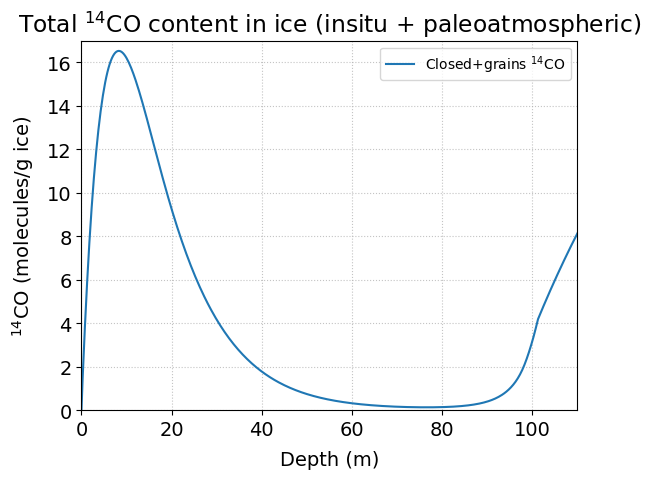

In [136]:
plt.plot(z, C14_closed[:,-1,1]+C14_grains[:,-1,1], label=r'Closed+grains $^{14}$CO')
plt.legend(fontsize=10)
plt.xlim(z[0],z[-1])
plt.xlabel('Depth (m)')
plt.ylim(0,17)
plt.ylabel(r'$^{14}$CO (molecules/g ice)')
plt.title(r'Total $^{14}$CO content in ice (insitu + paleoatmospheric)')

## Plot_C14_open_molec.m

Text(0.5, 1.0, 'Open porosity $^{14}$CO')

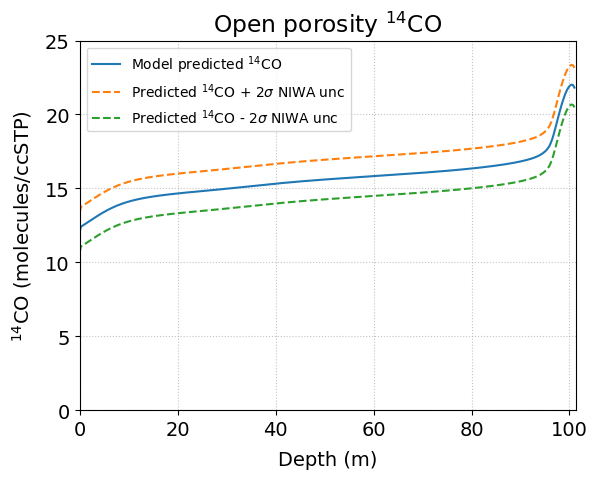

In [137]:
NIWA_14CO_unc = 0.67 #average 1-sigma uncertainty for NIWA 14CO measurements
firnprofile = C14_unit_convert(c_profiles[0],'ppm','molec')
plt.plot(z, firnprofile, label=r'Model predicted $^{14}$CO')
plt.plot(z,firnprofile+NIWA_14CO_unc*2,ls='--',label=r'Predicted $^{14}$CO + 2$\sigma$ NIWA unc')
plt.plot(z,firnprofile-NIWA_14CO_unc*2,ls='--',label=r'Predicted $^{14}$CO - 2$\sigma$ NIWA unc')
plt.legend(fontsize=10)
plt.xlim(z[0],z[teller_co])
plt.xlabel('Depth (m)')
plt.ylim(0,25)
plt.ylabel(r'$^{14}$CO (molecules/ccSTP)')
plt.title(r'Open porosity $^{14}$CO')